In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd

from lightgbm import LGBMRegressor
import lightgbm as lgb

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [2]:
!ls ../data/datasets/daily/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_daily_item__FOODS_1.parquet
dataset_level_10_daily_item__FOODS_2.parquet
dataset_level_10_daily_item__FOODS_3.parquet
dataset_level_10_daily_item__HOBBIES_1.parquet
dataset_level_10_daily_item__HOBBIES_2.parquet
dataset_level_10_daily_item__HOUSEHOLD_1.parquet
dataset_level_10_daily_item__HOUSEHOLD_2.parquet
dataset_level_11_daily_item_state__CA_FOODS_1.parquet
dataset_level_11_daily_item_state__CA_FOODS_2.parquet
dataset_level_11_daily_item_state__CA_FOODS_3.parquet
dataset_level_11_daily_item_state__CA_HOBBIES_1.parquet
dataset_level_11_daily_item_state__CA_HOBBIES_2.parquet
dataset_level_11_daily_item_state__CA_HOUSEHOLD_1.p

# Data

In [3]:
LEVEL = 'level_01_daily_total'
GRAIN = 'daily'
OBJECTIVE = "rmse"

In [4]:
import config

DATASET_PATH = f'../data/datasets/{GRAIN}/dataset_{LEVEL}.parquet'

SEASON_LENGTH = config.SEASON_LENGTH[GRAIN]
VALID_DAYS = config.valid_year_days(GRAIN)
TEST_DAYS = config.test_days(GRAIN)

In [5]:
df = pd.read_parquet(DATASET_PATH)
df = df.sort_values(['agg_id', 'date'])

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15,lag16,lag17,lag18,lag19,lag20,lag21,lag22,lag23,lag24,lag25,lag26,lag27,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag1_window_size7,rolling_std_lag1_window_size7,rolling_min_lag1_window_size7,rolling_max_lag1_window_size7,rolling_mean_lag1_window_size14,rolling_std_lag1_window_size14,rolling_min_lag1_window_size14,rolling_max_lag1_window_size14,rolling_mean_lag1_window_size21,rolling_std_lag1_window_size21,rolling_min_lag1_window_size21,rolling_max_lag1_window_size21,rolling_mean_lag1_window_size35,rolling_std_lag1_window_size35,rolling_min_lag1_window_size35,rolling_max_lag1_window_size35,rolling_mean_lag1_window_size7_truediv_rolling_mean_lag1_window_size35,rolling_mean_lag2_window_size7,rolling_std_lag2_window_size7,rolling_min_lag2_window_size7,rolling_max_lag2_window_size7,rolling_mean_lag2_window_size14,rolling_std_lag2_window_size14,rolling_min_lag2_window_size14,rolling_max_lag2_window_size14,rolling_mean_lag3_window_size7,rolling_std_lag3_window_size7,rolling_min_lag3_window_size7,rolling_max_lag3_window_size7,rolling_mean_lag3_window_size14,rolling_std_lag3_window_size14,rolling_min_lag3_window_size14,rolling_max_lag3_window_size14,rolling_mean_lag4_window_size7,rolling_std_lag4_window_size7,rolling_min_lag4_window_size7,rolling_max_lag4_window_size7,rolling_mean_lag4_window_size14,rolling_std_lag4_window_size14,rolling_min_lag4_window_size14,rolling_max_lag4_window_size14,rolling_mean_lag5_window_size7,rolling_std_lag5_window_size7,rolling_min_lag5_window_size7,rolling_max_lag5_window_size7,rolling_mean_lag5_window_size14,rolling_std_lag5_window_size14,rolling_min_lag5_window_size14,rolling_max_lag5_window_size14,rolling_mean_lag6_window_size7,rolling_std_lag6_window_size7,rolling_min_lag6_window_size7,rolling_max_lag6_window_size7,rolling_mean_lag6_window_size14,rolling_std_lag6_window_size14,rolling_min_lag6_window_size14,rolling_max_lag6_window_size14,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag36

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Columns: 193 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: category(10), datetime64[ms](1), float32(165), int16(1), int32(1), int8(15)
memory usage: 1.3 MB


# Variables

In [7]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES), "features disponibles")

182 features disponibles


# Split

In [8]:
from src.data import date_split

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 21:05:53.127 | INFO     | src.data.split:log_summary:46 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 1,549 rows)
2026-08-23 21:05:53.128 | INFO     | src.data.split:log_summary:47 - Valid : 2015-04-27 to 2016-04-24 (364 days, 364 rows)
2026-08-23 21:05:53.128 | INFO     | src.data.split:log_summary:48 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)


In [9]:
import gc
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET, GRAIN,
)

eval_cols = [c for c in ["agg_id", "date", "sales", "gross_sales", "avg_sell_price", "is_store_closed"]
             if c in df.columns]
train = train[eval_cols].copy()
valid = valid[eval_cols].copy()
test = test[eval_cols].copy()

del df, data_split
gc.collect()

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")

Cantidad features: 182 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [10]:
import time
from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [11]:
from src.modeling import seasonal_naive, drift, historical_mean, moving_average

In [12]:
SN_WINDOWS = {"daily": [1, 7, 28, 364], "weekly": [1, 4, 52]}[GRAIN]

for window in SN_WINDOWS:
    t0 = time.perf_counter()
    y_pred_sn= seasonal_naive(train, valid, TARGET, season_length=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Naive ({window}{GRAIN[0]})", y_pred_sn, fit_time=fit_time, category="Naive")

2026-08-23 21:05:53.590 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -        Naive (1d) [Naive] | WAPE: 16.71% | WRMSSE: 1.3011 | MAE: 6587.555 | RMSE: 7443.905 | SMAPE: 16.32% | Bias: 9.83% | RMSLE: 0.1892 | TS: -214.14 | SPEC: 2573012.900 | MASE: 1.5971 | fit: 0.01s
2026-08-23 21:05:53.613 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -        Naive (7d) [Naive] | WAPE: 12.32% | WRMSSE: 1.0032 | MAE: 4854.217 | RMSE: 5740.019 | SMAPE: 12.91% | Bias: -11.14% | RMSLE: 0.1510 | TS: 329.18 | SPEC: 6684895.527 | MASE: 1.1768 | fit: 0.01s
2026-08-23 21:05:53.627 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -       Naive (28d) [Naive] | WAPE: 10.65% | WRMSSE: 0.8999 | MAE: 4195.646 | RMSE: 5148.805 | SMAPE: 10.87% | Bias: -6.54% | RMSLE: 0.1317 | TS: 223.67 | SPEC: 1952087.791 | MASE: 1.0172 | fit: 0.00s
2026-08-23 21:05:53.642 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -      Naive (364d) [Naive] | WAPE: 9.99% | WRMSSE: 0.88

### Drift

In [13]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 21:05:53.682 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             Drift [Naive] | WAPE: 18.13% | WRMSSE: 1.4182 | MAE: 7146.439 | RMSE: 8114.246 | SMAPE: 17.56% | Bias: 13.04% | RMSLE: 0.2052 | TS: -261.86 | SPEC: 3623003.939 | MASE: 1.7326 | fit: 0.01s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.1813297411205828,
 'wrmsse': 1.4182151990020828,
 'mae': 7146.43923211801,
 'rmse': 8114.246451082559,
 'smape': 0.17562343299119915,
 'bias': 0.1304479775447261,
 'rmsle': 0.20523050242695934,
 'tracking_signal': -261.8603188470029,
 'spec': 3623003.939293346,
 'mase': 1.7325664384001742,
 'fit_time': 0.008299109002109617}

### Historical mean

In [14]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 21:05:53.709 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -   Historical mean [Naive] | WAPE: 17.35% | WRMSSE: 1.5712 | MAE: 6836.216 | RMSE: 8989.582 | SMAPE: 17.68% | Bias: -16.12% | RMSLE: 0.2261 | TS: 338.23 | SPEC: 14670681.705 | MASE: 1.6574 | fit: 0.00s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.1734583002623258,
 'wrmsse': 1.5712071676048138,
 'mae': 6836.2155842204675,
 'rmse': 8989.582252837017,
 'smape': 0.17675097943832788,
 'bias': -0.1611768390275734,
 'rmsle': 0.2260691318814631,
 'tracking_signal': 338.22751241832134,
 'spec': 14670681.705024466,
 'mase': 1.657356524303408,
 'fit_time': 0.0027579010056797415}

### Moving average

In [15]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 21:05:53.740 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (7d) [Naive] | WAPE: 14.41% | WRMSSE: 1.3504 | MAE: 5680.401 | RMSE: 7726.051 | SMAPE: 14.34% | Bias: -11.14% | RMSLE: 0.1888 | TS: 281.42 | SPEC: 6571027.244 | MASE: 1.3771 | fit: 0.00s
2026-08-23 21:05:53.757 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (14d) [Naive] | WAPE: 13.81% | WRMSSE: 1.2940 | MAE: 5443.858 | RMSE: 7403.820 | SMAPE: 13.68% | Bias: -9.64% | RMSLE: 0.1800 | TS: 253.96 | SPEC: 4756044.330 | MASE: 1.3198 | fit: 0.00s
2026-08-23 21:05:53.772 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (21d) [Naive] | WAPE: 13.18% | WRMSSE: 1.2238 | MAE: 5193.970 | RMSE: 7001.966 | SMAPE: 13.00% | Bias: -7.46% | RMSLE: 0.1696 | TS: 206.15 | SPEC: 2657895.809 | MASE: 1.2592 | fit: 0.00s
2026-08-23 21:05:53.786 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (28d) [Naive] | WAPE: 13.00% | 

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [16]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [17]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-23 21:05:56.572 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -      SARIMA [Statistical] | WAPE: 13.00% | WRMSSE: 1.0594 | MAE: 5123.622 | RMSE: 6061.570 | SMAPE: 13.59% | Bias: -11.94% | RMSLE: 0.1586 | TS: 334.43 | SPEC: 7228896.053 | MASE: 1.2422 | fit: 2.53s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.1300039148278513,
 'wrmsse': 1.0594466633323334,
 'mae': 5123.622145563338,
 'rmse': 6061.5704401592875,
 'smape': 0.13593290671183597,
 'bias': -0.1194435722822369,
 'rmsle': 0.15855161631490902,
 'tracking_signal': 334.4319312868866,
 'spec': 7228896.052754432,
 'mase': 1.2421592745868804,
 'fit_time': 2.5263294839969603}

### ETS (Holt-Winters)

In [18]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-23 21:05:58.071 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - ETS (Holt-Winters) [Statistical] | WAPE: 9.39% | WRMSSE: 0.8180 | MAE: 3701.513 | RMSE: 4680.291 | SMAPE: 9.54% | Bias: -7.61% | RMSLE: 0.1188 | TS: 294.86 | SPEC: 3427893.565 | MASE: 0.8974 | fit: 1.46s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.09392011113240722,
 'wrmsse': 0.818025491163355,
 'mae': 3701.5128502013345,
 'rmse': 4680.291427731041,
 'smape': 0.095370160416331,
 'bias': -0.07607925894890974,
 'rmsle': 0.11883548859931975,
 'tracking_signal': 294.8553821274994,
 'spec': 3427893.564584642,
 'mase': 0.897386338463992,
 'fit_time': 1.4561410609967425}

### Theta

In [19]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-23 21:05:59.581 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -       Theta [Statistical] | WAPE: 9.31% | WRMSSE: 0.8198 | MAE: 3667.661 | RMSE: 4690.516 | SMAPE: 9.30% | Bias: -7.47% | RMSLE: 0.1162 | TS: 292.22 | SPEC: 3098161.089 | MASE: 0.8892 | fit: 1.49s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.093061172029193,
 'wrmsse': 0.8198125388276511,
 'mae': 3667.660951073941,
 'rmse': 4690.515930456815,
 'smape': 0.09299902825036288,
 'bias': -0.07471091595373996,
 'rmsle': 0.11615204016920698,
 'tracking_signal': 292.22470353833955,
 'spec': 3098161.0889825206,
 'mase': 0.8891793611989173,
 'fit_time': 1.4882804039953044}

### TBATS

In [20]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
2026-08-23 21:06:06.732 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -       TBATS [Statistical] | WAPE: 10.57% | WRMSSE: 0.9065 | MAE: 4166.548 | RMSE: 5186.326 | SMAPE: 10.68% | Bias: -9.12% | RMSLE: 0.1297 | TS: 314.16 | SPEC: 4281073.044 | MASE: 1.0101 | fit: 7.13s


{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.10571966295590204,
 'wrmsse': 0.9064706379769163,
 'mae': 4166.548423250312,
 'rmse': 5186.325856887065,
 'smape': 0.10679938738445018,
 'bias': -0.09124335556887585,
 'rmsle': 0.12971315480401016,
 'tracking_signal': 314.1570877020719,
 'spec': 4281073.044216711,
 'mase': 1.010128502828281,
 'fit_time': 7.128104474999418}

### Prophet

In [21]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

21:06:08 - cmdstanpy - INFO - Chain [1] start processing
21:06:08 - cmdstanpy - INFO - Chain [1] done processing
2026-08-23 21:06:08.561 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -     Prophet [Statistical] | WAPE: 11.09% | WRMSSE: 0.9232 | MAE: 4370.270 | RMSE: 5282.309 | SMAPE: 11.32% | Bias: -9.77% | RMSLE: 0.1335 | TS: 320.64 | SPEC: 4572068.141 | MASE: 1.0595 | fit: 1.80s


{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.11088877268392557,
 'wrmsse': 0.9232467352873392,
 'mae': 4370.2697120316425,
 'rmse': 5282.309448206563,
 'smape': 0.11320622616903978,
 'bias': -0.09767917368185963,
 'rmsle': 0.13351391774629667,
 'tracking_signal': 320.6385854909096,
 'spec': 4572068.141227728,
 'mase': 1.059518227734058,
 'fit_time': 1.795673700995394}

## Modelos Machine Learning

In [22]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

### LightGBM

In [23]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 21:06:09.334 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             LightGBM [ML] | WAPE: 10.50% | WRMSSE: 0.8889 | MAE: 4137.741 | RMSE: 5085.764 | SMAPE: 10.65% | Bias: -10.01% | RMSLE: 0.1267 | TS: 347.09 | SPEC: 5149478.572 | MASE: 1.0031 | fit: 0.72s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.10498870770483207,
 'wrmsse': 0.8888943909775655,
 'mae': 4137.740532989798,
 'rmse': 5085.764249637204,
 'smape': 0.1064619684814174,
 'bias': -0.10011267129163089,
 'rmsle': 0.12673263264802084,
 'tracking_signal': 347.0945889971789,
 'spec': 5149478.571805265,
 'mase': 1.0031443835759732,
 'fit_time': 0.7202106350014219}

### XGBoost

In [24]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 21:06:14.860 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -              XGBoost [ML] | WAPE: 6.92% | WRMSSE: 0.6482 | MAE: 2727.080 | RMSE: 3708.525 | SMAPE: 6.73% | Bias: -5.27% | RMSLE: 0.0876 | TS: 277.08 | SPEC: 1189079.101 | MASE: 0.6611 | fit: 5.47s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.06919540387095689,
 'wrmsse': 0.6481793157266805,
 'mae': 2727.0802122682007,
 'rmse': 3708.5251349732685,
 'smape': 0.06733999163759394,
 'bias': -0.05267156454677914,
 'rmsle': 0.08756991826035336,
 'tracking_signal': 277.07692162303834,
 'spec': 1189079.1005255731,
 'mase': 0.6611471107690076,
 'fit_time': 5.4666124020004645}

### CatBoost

In [25]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-23 21:06:22.405 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             CatBoost [ML] | WAPE: 18.12% | WRMSSE: 1.4485 | MAE: 7141.914 | RMSE: 8287.494 | SMAPE: 19.16% | Bias: -18.04% | RMSLE: 0.2156 | TS: 362.33 | SPEC: 18131822.340 | MASE: 1.7315 | fit: 7.48s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.18121491373830356,
 'wrmsse': 1.4484955979838832,
 'mae': 7141.913736716261,
 'rmse': 8287.494220637085,
 'smape': 0.19158062198886508,
 'bias': -0.1803857680696608,
 'rmsle': 0.21558225229043335,
 'tracking_signal': 362.3345243657936,
 'spec': 18131822.339885365,
 'mase': 1.7314692876100344,
 'fit_time': 7.48458876299992}

### HistGradientBoosting (sklearn)

In [26]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-23 21:06:23.323 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - HistGradientBoosting [ML] | WAPE: 7.00% | WRMSSE: 0.6541 | MAE: 2757.228 | RMSE: 3742.658 | SMAPE: 6.81% | Bias: -4.96% | RMSLE: 0.0886 | TS: 258.16 | SPEC: 1117507.604 | MASE: 0.6685 | fit: 0.87s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.06996036878361582,
 'wrmsse': 0.6541451082926778,
 'mae': 2757.228467205509,
 'rmse': 3742.6581150672628,
 'smape': 0.06808510540684105,
 'bias': -0.04961872709302855,
 'rmsle': 0.08859296859112416,
 'tracking_signal': 258.1635428155746,
 'spec': 1117507.6035038987,
 'mase': 0.6684561849784347,
 'fit_time': 0.8690494399997988}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [27]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-23 21:06:23.517 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -                Ridge [ML] | WAPE: 13.03% | WRMSSE: 1.1192 | MAE: 5136.931 | RMSE: 6403.254 | SMAPE: 13.56% | Bias: -8.90% | RMSLE: 0.1683 | TS: 248.48 | SPEC: 3256814.155 | MASE: 1.2454 | fit: 0.15s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.13034159412113952,
 'wrmsse': 1.1191664829518264,
 'mae': 5136.930522526299,
 'rmse': 6403.254364254681,
 'smape': 0.13560476042551067,
 'bias': -0.08897724675031105,
 'rmsle': 0.16829386411889088,
 'tracking_signal': 248.48336431279228,
 'spec': 3256814.1549847038,
 'mase': 1.2453857271637074,
 'fit_time': 0.14946526400308358}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [28]:
# import json

# # Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
# nn_result_json = """
# {
#   "model": "Red neuronal (PyTorch)",
#   "category": "Neural Network",
#   "wape": 0.10028197523732978,
#   "wrmsse": 0.6648106210840594,
#   "mae": 56.451958003855964,
#   "rmse": 101.11262700533668,
#   "mape": 0.14361555839435278,
#   "smape": 0.13450871897523384,
#   "bias": -0.01973313975149749,
#   "rmsle": 0.18986484887682267,
#   "tracking_signal": 5027.640505260812,
#   "spec": 24816.267370544832,
#   "mase": 0.6779046862289563,
#   "fit_time": 27.297044813000014
# }
# """

# nn_result = json.loads(nn_result_json)
# if nn_result.get("model"):
#     model_results.append(nn_result)
#     print(f"Agregado: {nn_result['model']}")
# else:
#     print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

## Resultados

In [29]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [30]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
17,XGBoost,ML,0.069195,0.648179,2727.080212,3708.525135,0.067340,-0.052672,0.087570,277.076922,1.189079e+06,0.661147,5.466612
19,HistGradientBoosting,ML,0.069960,0.654145,2757.228467,3742.658115,0.068085,-0.049619,0.088593,258.163543,1.117508e+06,0.668456,0.869049
12,ETS (Holt-Winters),Statistical,0.093920,0.818025,3701.512850,4680.291428,0.095370,-0.076079,0.118835,294.855382,3.427894e+06,0.897386,1.456141
13,Theta,Statistical,0.093061,0.819813,3667.660951,4690.515930,0.092999,-0.074711,0.116152,292.224704,3.098161e+06,0.889179,1.488280
3,Naive (364d),Naive,0.099856,0.886003,3935.450549,5069.220003,0.106555,-0.089758,0.563641,327.189475,3.879820e+06,0.954102,0.002533
16,LightGBM,ML,0.104989,0.888894,4137.740533,5085.764250,0.106462,-0.100113,0.126733,347.094589,5.149479e+06,1.003144,0.720211
2,Naive (28d),Naive,0.106458,0.899913,4195.645604,5148.805399,0.108684,-0.065417,0.131704,223.674516,1.952088e+06,1.017183,0.002625
14,TBATS,Statistical,0.105720,0.906471,4166.548423,5186.325857,0.106799,-0.091243,0.129713,314.157088,4.281073e+06,1.010129,7.128104
15,Prophet,Statistical,0.110889,0.923247,4370.269712,5282.309448,0.113206,-0.097679,0.133514,320.638585,4.572068e+06,1.059518,1.795674
1,Naive (7d),Naive,0.123168,1.003246,4854.217033,5740.019195,0.129135,-0.111386,0.151018,329.179554,6.684896e+06,1.176845,0.006494


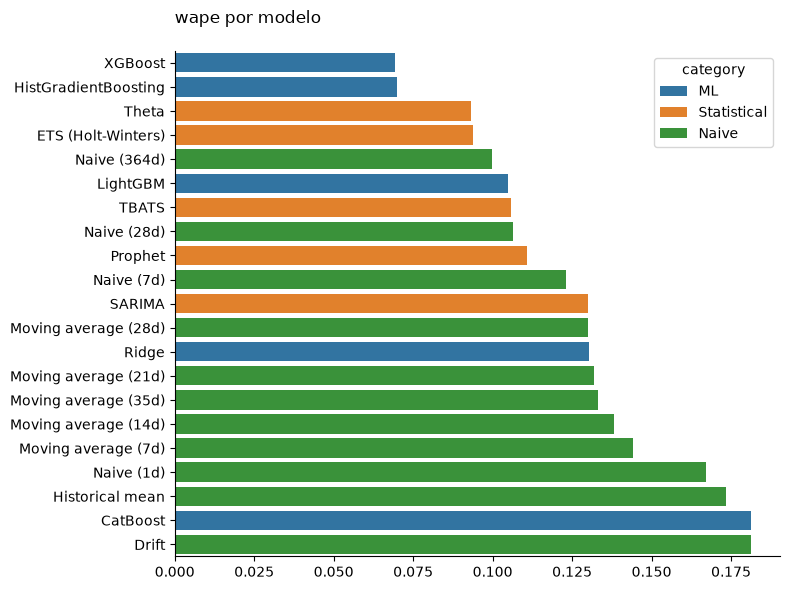

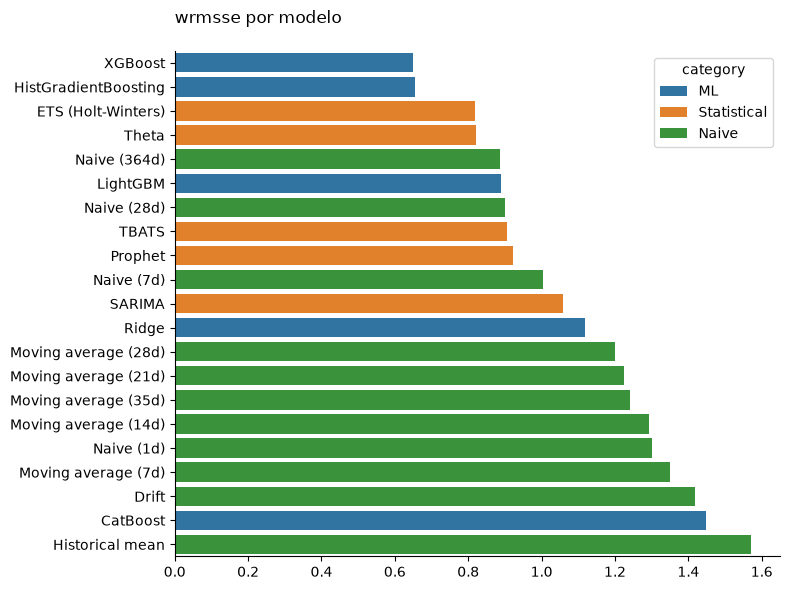

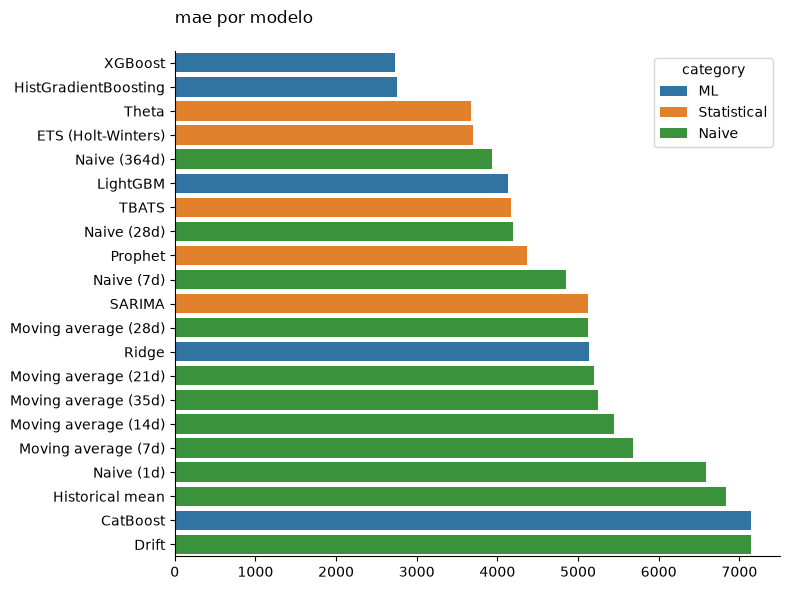

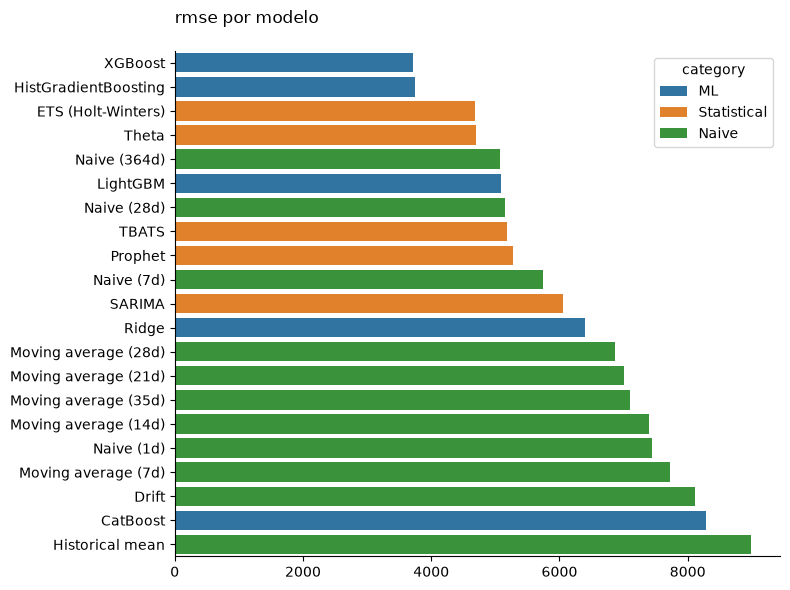

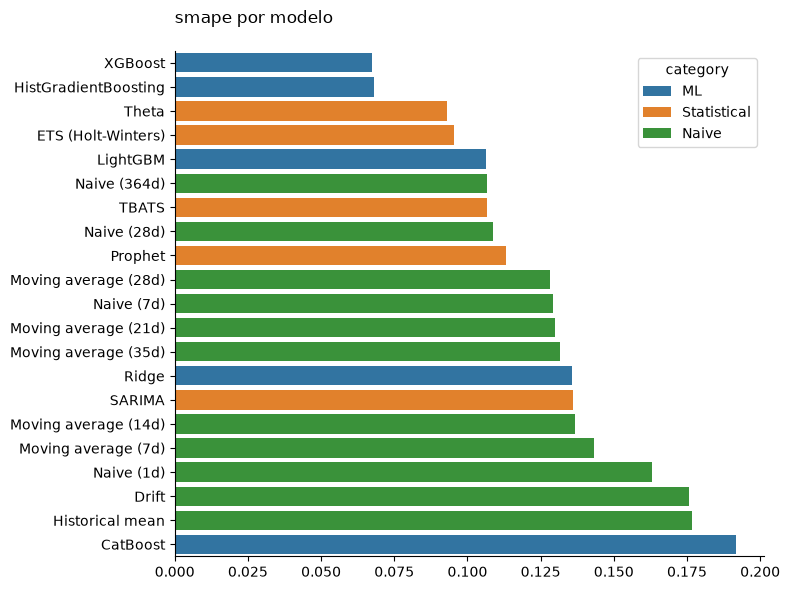

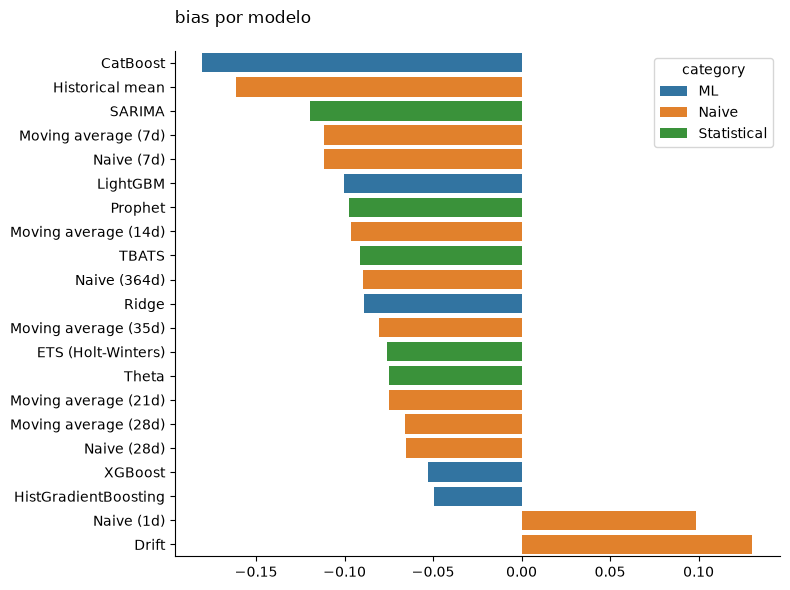

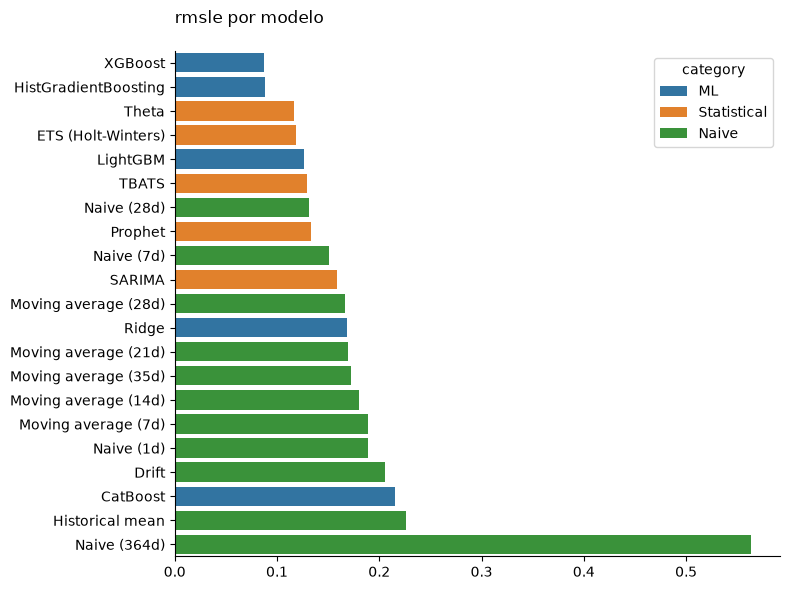

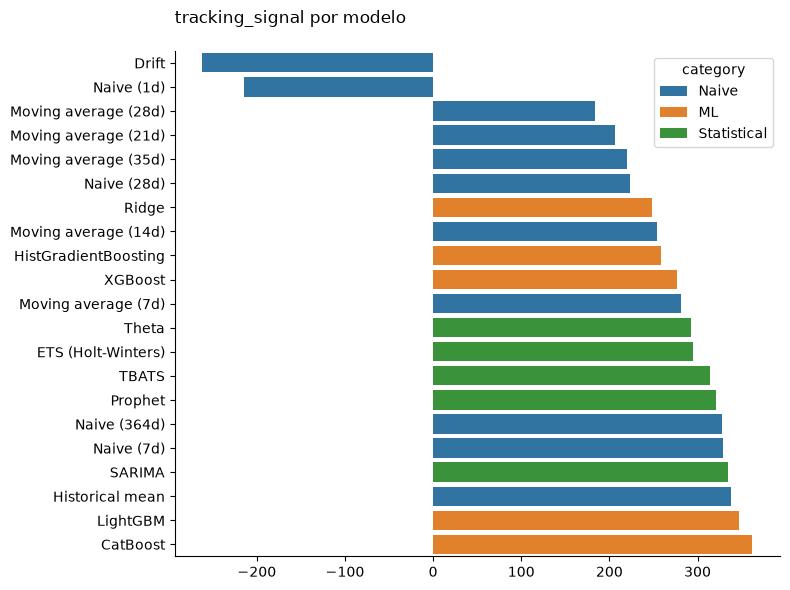

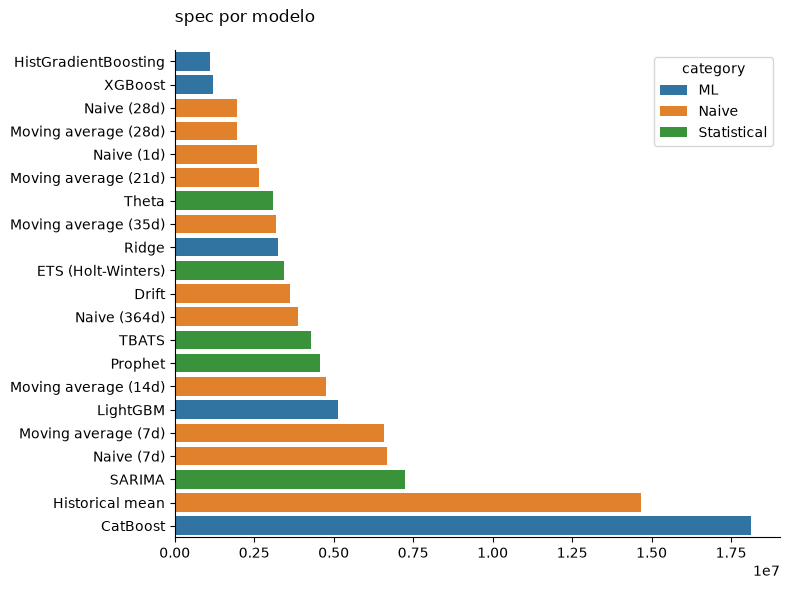

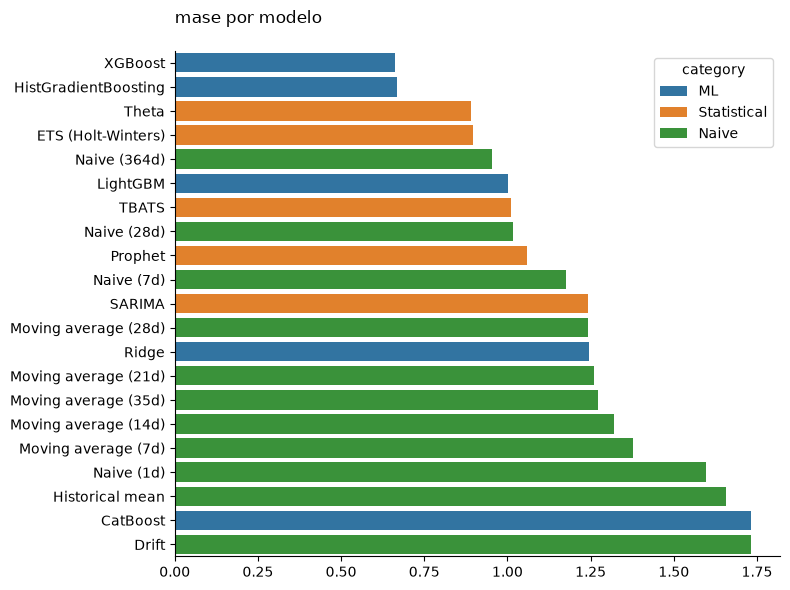

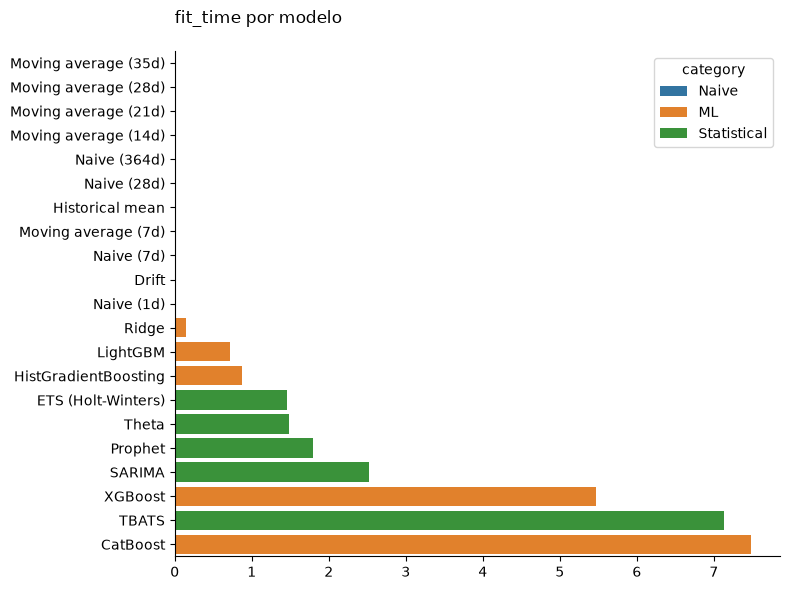

In [31]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [32]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

lag28                             2.290888e+11
lag364                            3.272092e+10
lag182                            1.903597e+10
lag7                              1.235672e+10
dayofweek                         1.230902e+10
day                               1.143576e+10
lag1                              9.088681e+09
lag91                             6.985429e+09
price_change                      5.899196e+09
days_to_closure                   3.415616e+09
price_vs_max                      3.282233e+09
rolling_mean_lag1_window_size7    2.450594e+09
avg_sell_price                    2.146760e+09
lag14                             2.127060e+09
lag35                             1.786396e+09
rolling_max_lag2_window_size7     1.591387e+09
lag21                             1.542826e+09
days_since_thanksgiving           1.491250e+09
doy_cos                           1.393382e+09
rolling_max_lag3_window_size7     1.165846e+09
dtype: float64

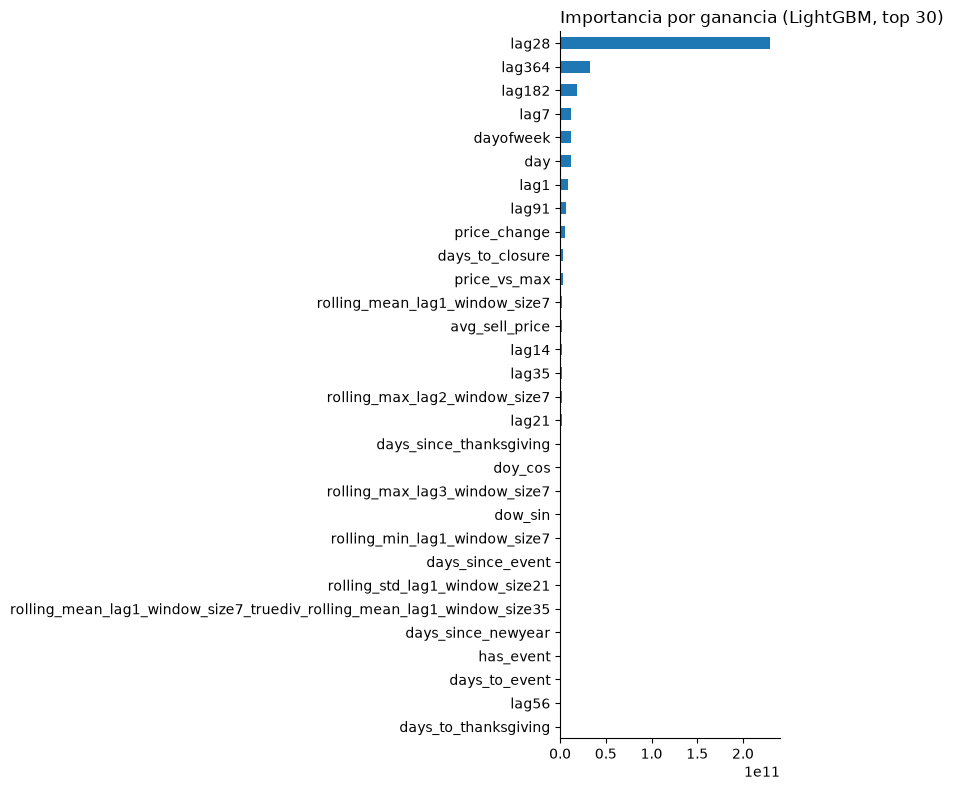

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

In [34]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=300_000, n_repeats=5, random_state=RANDOM_STATE,
)
importance_perm.head(20)

lag28                              710.219189
lag364                             584.611783
lag182                             412.113413
dayofweek                          283.927608
day                                200.897140
days_to_closure                    154.406839
lag21                               66.253054
price_change                        62.206852
days_since_thanksgiving             42.133967
avg_sell_price                      26.705233
lag8                                25.917608
dow_sin                             23.551559
has_event                           22.859359
event_type_1_enc                    21.928717
lag3                                19.658919
price_vs_max                        19.080710
rolling_std_lag4_window_size7       15.687863
days_to_newyear                     10.809775
days_to_event                       10.010393
rolling_std_lag28_window_size28      9.460423
dtype: float64

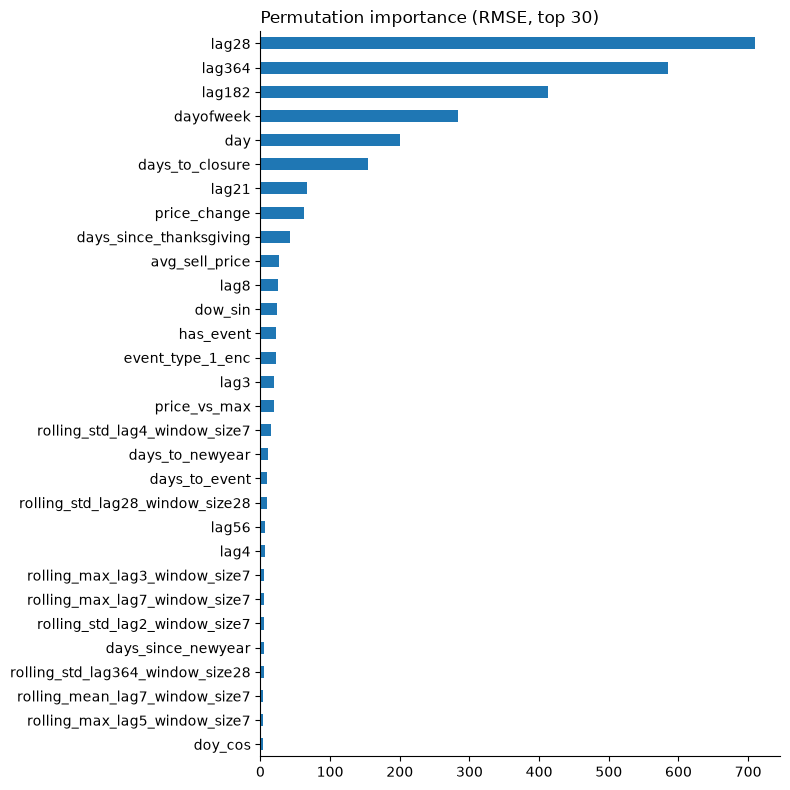

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [36]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.0, random_state=RANDOM_STATE,
)

2026-08-23 21:06:31.693 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (182 features): WRMSSE=0.8889
2026-08-23 21:06:32.596 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'lag5' -> 181 features | WRMSSE=0.8742
2026-08-23 21:06:33.367 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'lag7' | WRMSSE empeoraría a 0.9015
2026-08-23 21:06:34.245 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'lag1' -> 180 features | WRMSSE=0.8565
2026-08-23 21:06:35.076 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_min_lag1_window_size7' -> 179 features | WRMSSE=0.8537
2026-08-23 21:06:35.664 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'lag15' | WRMSSE empeoraría a 0.8672
2026-08-23 21:06:36.520 | WARNING  | src.modeling.feature_selection:backward_feature_selectio

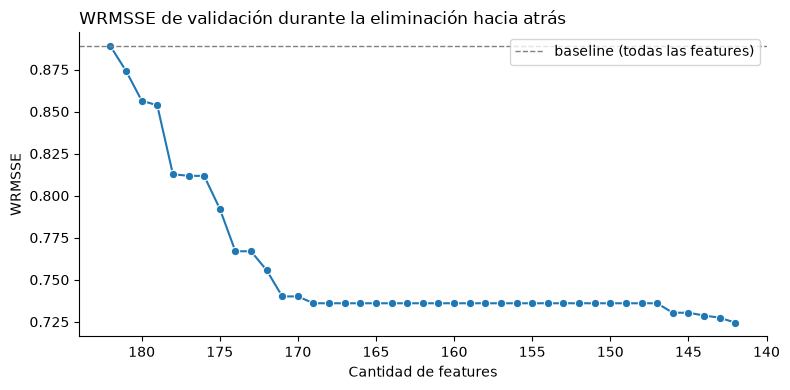

In [37]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [38]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (40): ['cat_id', 'dept_id', 'dow_cos', 'event_name_1', 'event_name_2', 'event_type_1', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_likely_stockout', 'is_month_end', 'is_month_start', 'is_store_closed', 'is_weekend', 'item_id', 'lag1', 'lag10', 'lag19', 'lag5', 'month', 'pct_zero_28', 'pct_zero_90', 'price_vs_mean', 'quarter', 'rolling_max_lag7_window_size14', 'rolling_mean_lag364_window_size91', 'rolling_mean_lag365_window_size91', 'rolling_mean_lag4_window_size14', 'rolling_mean_lag5_window_size14', 'rolling_mean_lag6_window_size7', 'rolling_min_lag1_window_size7', 'rolling_min_lag4_window_size14', 'rolling_min_lag6_window_size7', 'rolling_std_lag28_window_size91', 'snap', 'state_id', 'store_id', 'year', 'zero_streak']
Features finales: 142 (0 categóricas)


# Modelo con variables seleccionadas

In [39]:
from src.evaluation import make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)

In [40]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 6282.93	valid_0's wrmsse: 1.05627
[20]	valid_0's rmse: 5769.65	valid_0's wrmsse: 0.962783
[30]	valid_0's rmse: 5566.89	valid_0's wrmsse: 0.927767
[40]	valid_0's rmse: 5220.16	valid_0's wrmsse: 0.869879
[50]	valid_0's rmse: 4896.03	valid_0's wrmsse: 0.81498
[60]	valid_0's rmse: 4754.08	valid_0's wrmsse: 0.793044
[70]	valid_0's rmse: 4619.28	valid_0's wrmsse: 0.771948
[80]	valid_0's rmse: 4555.32	valid_0's wrmsse: 0.763604


2026-08-23 21:12:21.791 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - LightGBM (selected features) [ML] | WAPE: 7.95% | WRMSSE: 0.7245 | MAE: 3134.109 | RMSE: 4145.101 | SMAPE: 7.83% | Bias: -6.71% | RMSLE: 0.0994 | TS: 307.21 | SPEC: 2066026.800 | MASE: 0.7598 | fit: 0.84s


[90]	valid_0's rmse: 4404.83	valid_0's wrmsse: 0.73865
[100]	valid_0's rmse: 4314.77	valid_0's wrmsse: 0.724484
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 4314.77	valid_0's wrmsse: 0.724484
Evaluated only: rmse


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.07952312478879442,
 'wrmsse': 0.7244844669512879,
 'mae': 3134.10902888422,
 'rmse': 4145.10119406448,
 'smape': 0.0782550090644928,
 'bias': -0.06711717941493543,
 'rmsle': 0.09941144645832259,
 'tracking_signal': 307.2144533042672,
 'spec': 2066026.7997879907,
 'mase': 0.7598262493197527,
 'fit_time': 0.8373808249962167}

## Explicación modelo

In [41]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                               feature  mean_abs_shap
47                               lag28    3253.595611
53                              lag364     856.701596
3                                  day     701.146050
4                            dayofweek     657.164071
28                                lag7     572.710244
..                                 ...            ...
61     rolling_mean_lag1_window_size21       2.801238
111     rolling_min_lag7_window_size14       1.683938
141  rolling_mean_lag365_window_size28       1.682206
107      rolling_min_lag7_window_size7       1.537020
89       rolling_max_lag4_window_size7       1.388927

[142 rows x 2 columns]


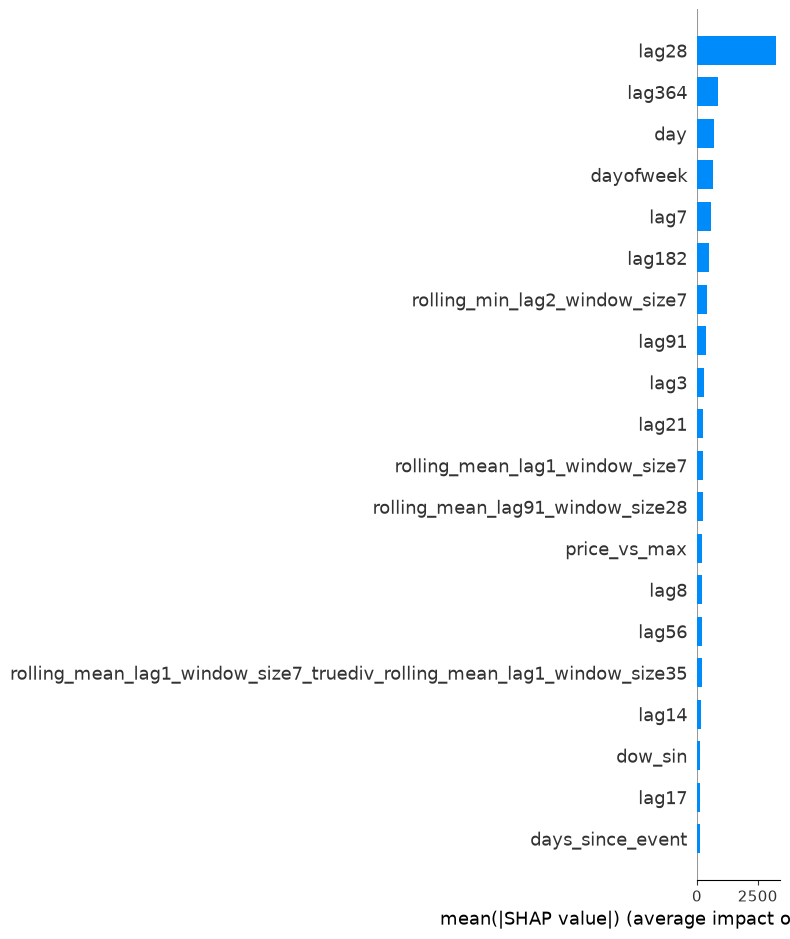

In [42]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

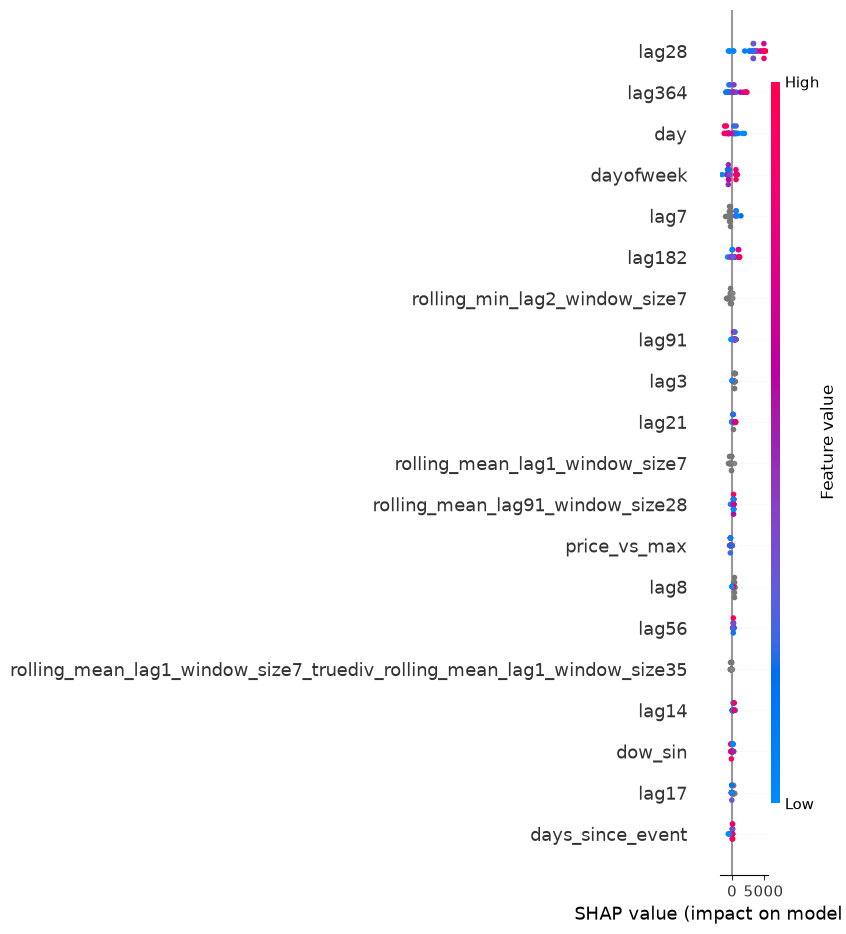

In [43]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [44]:
from src.evaluation import plot_forecast
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [45]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 13.86%
Test WRMSSE: 1.2222


# Modelo optimizado

In [46]:
import optuna
from optuna.integration import LightGBMPruningCallback

In [47]:
def objective(trial):
    params = dict(
        objective=OBJECTIVE,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    if OBJECTIVE == "tweedie":
        params["tweedie_variance_power"] = trial.suggest_float(
            "tweedie_variance_power", 1.1, 1.9
        )

    eval_metric = "tweedie" if OBJECTIVE == "tweedie" else "rmse"

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=eval_metric,
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, eval_metric),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [ ]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 10,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-23 21:12:23,071] A new study created in RDB with name: study_level_01_daily_total


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-08-23 21:12:25,051] Trial 0 finished with value: 0.8115008042085853 and parameters: {'learning_rate': 0.054816785328198704, 'num_leaves': 244, 'max_depth': 9, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044}. Best is trial 0 with value: 0.8115008042085853.
[I 2026-08-23 21:12:27,422] Trial 1 finished with value: 0.7391380063996533 and parameters: {'learning_rate': 0.07893736353172352, 'num_leaves': 190, 'max_depth': 5, 'min_child_samples': 195, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.004705059281907645, 'reg_lambda': 0.004768785415482609}. Best is trial 1 with value: 0.7391380063996533.
[I 2026-08-23 21:12:30,324] Trial 2 finished with value: 0.8032926698864487 and parameters: {'learning_rate': 0.048952790869270256, 'num_leaves': 149, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.8447411578889518, 'colsam

# Modelo final

In [ ]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective=OBJECTIVE,
    n_estimators=3_000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

## Resultados finales

In [ ]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

# Exportar

In [ ]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

# No se guardan df/X_train/y_train/X_valid/y_valid/valid: reconstruibles desde el
# parquet en data/datasets/ + este mismo notebook, y notebooks/03_predictions.ipynb
# no los usa -- guardarlos solo triplicaba el tamaño del artifact (y el pico de RAM
# al armarlo) sin necesidad, justo lo que hace fallar por memoria al nivel 12.
artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "objective": OBJECTIVE,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    #"df_pred": df_pred,
    #"df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")